In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

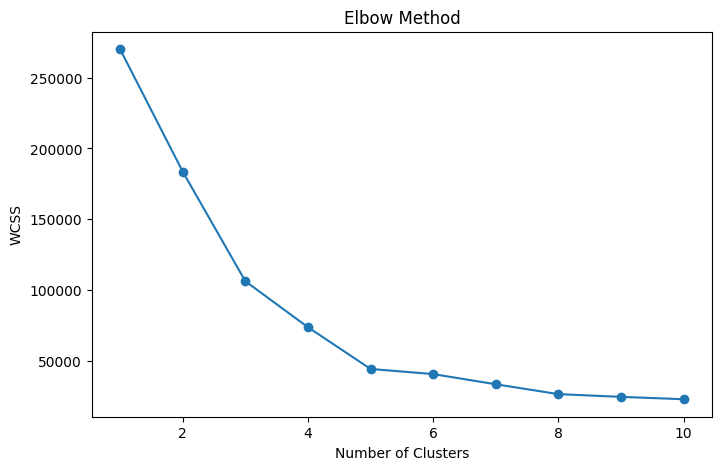

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans

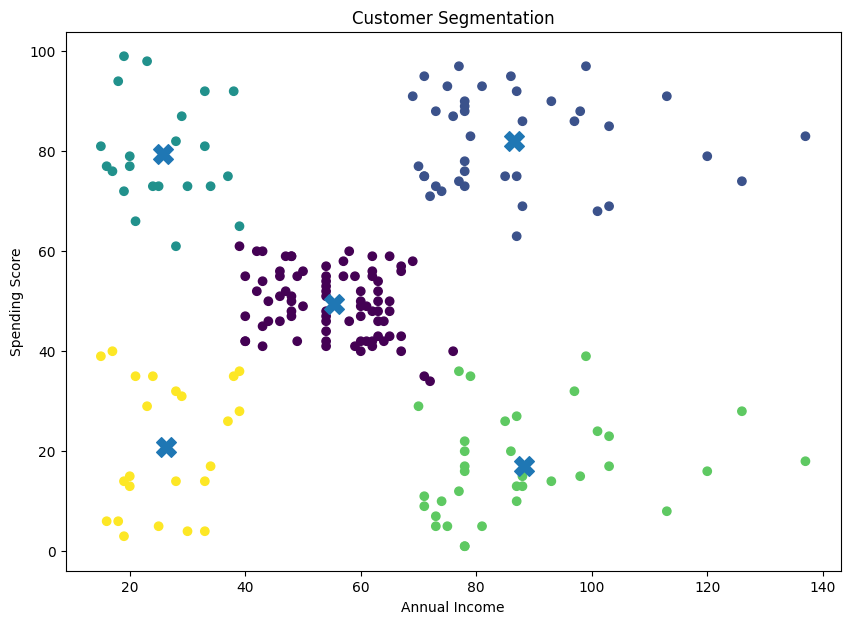

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation')
plt.show()